In [23]:
from sage.all import *
from sage.all import *

def galois_orbit_sum(N, k, prec=20):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')
    R.<q> = PowerSeriesRing(QQ, default_prec=prec)

    results = []
    for i, f in enumerate(newforms):
        K = f.base_ring()
        qexp = f.q_expansion(prec)
        deg = 1 if K == QQ else K.degree()

        coeffs = []
        for n in range(prec):
            c = qexp[n]
            coeffs.append(QQ(c) if K == QQ else QQ(K(c).trace()))

        trace_qexp = sum(coeffs[n] * q**n for n in range(prec)) + O(q**prec)

        print(f"Orbit {i}: degree {deg} over Q")
        print(f"  q-expansion: {trace_qexp}")
        print(f"  coefficients: {coeffs[1:]}")
        print()
        results.append(coeffs)
    print("len(results):",len(results))

    return results[0] # len(results) = number of distinct Galois orbits of newforms)

galois_orbit_sum(11, 4)
    print("len(results):",len(results))
    
N=11
k=4
S = CuspForms(N,k)
dim=S.dimension()
newforms = S.newforms(names='a')
print("dim(S):",dim)

for f in newforms:
    print("Minimal polynomial of a0:", f.base_ring().polynomial())
    print("q-expansion:")
    print(f.q_expansion(20))
    print()

    # Substitute the two conjugate values of a0 to get numerical forms
    K = f.base_ring()
    a0 = K.gen()
    print("a0 =", a0.minpoly())
    for emb in K.embeddings(CC):
        coeffs = [emb(f.q_expansion(20)[n]) for n in range(20)]
        print("Numerical coefficients:", coeffs[:10])

dim(S): 2
Minimal polynomial of a0: x^2 - 2*x - 2
q-expansion:
q + a0*q^2 + (-4*a0 + 3)*q^3 + (2*a0 - 6)*q^4 + (8*a0 - 7)*q^5 + (-5*a0 - 8)*q^6 + (-4*a0 + 14)*q^7 + (-10*a0 + 4)*q^8 + (8*a0 + 14)*q^9 + (9*a0 + 16)*q^10 - 11*q^11 + (14*a0 - 34)*q^12 + (-20*a0 + 60)*q^13 + (6*a0 - 8)*q^14 + (-12*a0 - 85)*q^15 + (-32*a0 + 28)*q^16 + (12*a0 - 74)*q^17 + (30*a0 + 16)*q^18 + (60*a0 - 24)*q^19 + O(q^20)

a0 = x^2 - 2*x - 2
Numerical coefficients: [0.000000000000000, 1.00000000000000, -0.732050807568877, 5.92820323027551, -7.46410161513775, -12.8564064605510, -4.33974596215561, 16.9282032302755, 11.3205080756888, 8.14359353944898]
Numerical coefficients: [0.000000000000000, 1.00000000000000, 2.73205080756888, -7.92820323027551, -0.535898384862246, 14.8564064605510, -21.6602540378444, 3.07179676972449, -23.3205080756888, 35.8564064605510]


In [7]:
from sage.all import *
k=4
levels=[]
for N in range(1, 15):
    try:
        nf = Newforms(N, k, names='a')
        if len(nf)>0:
            levels.append((N,len(nf)))
    except Exception:
        pass
if levels!=[]:
    for pair in levels:
        print(pair)

(5, 1)
(6, 1)
(7, 1)
(8, 1)
(9, 1)
(10, 1)
(11, 1)
(12, 1)
(13, 2)
(14, 2)


In [18]:
# Step 2b: retrieve the one you want
k, N = 4, 11
nf = Newforms(N, k, names='a')
for index in range(0,len(nf)):
    print("index:",index)
    f = nf[index]
    expansion = f.q_expansion(401)
    coeffs = [expansion[n] for n in range(1, 401)]
    print(coeffs[:20])
    print()


index: 0
[1, a0, -4*a0 + 3, 2*a0 - 6, 8*a0 - 7, -5*a0 - 8, -4*a0 + 14, -10*a0 + 4, 8*a0 + 14, 9*a0 + 16, -11, 14*a0 - 34, -20*a0 + 60, 6*a0 - 8, -12*a0 - 85, -32*a0 + 28, 12*a0 - 74, 30*a0 + 16, 60*a0 - 24, -30*a0 + 74]



In [17]:
#exact list of generators for the coefficient field = roots of
# its mimimal polynomial.
S = CuspForms(11, 4)
f = S.newforms(names='a')[0]
K = f.base_ring()
poly = K.polynomial()
print(poly.roots(ring=SR, multiplicities=False)) # <<<<<<< the generators

[-sqrt(3) + 1, sqrt(3) + 1]


In [ ]:
``In what sense do these generators generate the field?

``In the sense that every element of the field Q(a0) can be written as a polynomial in a0 with rational coefficients. That is, every element has the form
\[
c_0 + c_1 a_0 + c_2 a_0^2 + \cdots + c_{d-1} a_0^{d-1}
\]
where c0,c1,…,cd−1∈Q and 
d is the degree of the minimal polynomial. The minimal polynomial is what allows you to reduce any higher power of a0 back down to degree less than dd
d --- for example in the weight-4 level-11 case, a02=2a0+2a_0^2 = 2a_0 + 2
a02​=2a0​+2, so nothing of degree 2 or higher ever appears irreducibly.

So the field is just Q extended by one algebraic number a_0
and that single number is enough to reach everything in the field by rational arithmetic operations.


In [2]:
# this inputs level as N, weight as k, desired dinensjon as dim and finds those N such 
# that fit the description.
from sage.all import *
k = 4
dim = 2
lst=[]
# Step 1: Find candidates by dimension (cheap)
for N in range(1, 500):
    S = CuspForms(N, k)
    d = S.dimension()
    if d ==dim:
        lst.append(N)
print(lst)

[11]


In [14]:
from sage.all import *

def galois_orbit_sum(N, k, prec=20):
    """
    For each Galois orbit of newforms in S_k(Gamma_0(N)),
    compute the sum over the full orbit (= trace to Q),
    yielding a q-expansion with rational coefficients.
    """
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')
    R.<q> = PowerSeriesRing(QQ, default_prec=prec)

    results = []
    for i, f in enumerate(newforms):
        K = f.base_ring()
        qexp = f.q_expansion(prec)
        deg = 1 if K == QQ else K.degree()

        coeffs = []
        for n in range(prec):
            c = qexp[n]
            coeffs.append(QQ(c) if K == QQ else QQ(K(c).trace()))

        trace_qexp = sum(coeffs[n] * q**n for n in range(prec)) + O(q**prec)

        print(f"Orbit {i}: degree {deg} over Q")
        print(f"  {trace_qexp}")
        print()
        results.append(trace_qexp)

    return results


galois_orbit_sum(11, 4) # 2nd input is 4 bc I set k = 4 in the prior cell

Orbit 0: degree 2 over Q
  2*q + 2*q^2 - 2*q^3 - 8*q^4 + 2*q^5 - 26*q^6 + 20*q^7 - 12*q^8 + 44*q^9 + 50*q^10 - 22*q^11 - 40*q^12 + 80*q^13 - 4*q^14 - 194*q^15 - 8*q^16 - 124*q^17 + 92*q^18 + 72*q^19 + O(q^20)



[2*q + 2*q^2 - 2*q^3 - 8*q^4 + 2*q^5 - 26*q^6 + 20*q^7 - 12*q^8 + 44*q^9 + 50*q^10 - 22*q^11 - 40*q^12 + 80*q^13 - 4*q^14 - 194*q^15 - 8*q^16 - 124*q^17 + 92*q^18 + 72*q^19 + O(q^20)]

dimension: 2

Orbit 0: degree 2 over Q

coefficients: [2, 2, -2, -8, 2, -26, 20, -12, 44, 50, -22, -40, 80, -4, -194, -8, -124, 92, 72]

number of orbits: 1
[]
('j_list', 1)
('j_list', 17)
('j_list', 26)
('j_list', 29)
('j_list', 52)
('j_list', 57)
('j_list', 82)
('j_list', 92)
('j_list', 98)
('j_list', 188)
('j_list', 244)
('j_list', 248)
('j_list', 268)
('j_list', 276)
('j_list', 314)
('j_list', 336)
('j_list', 338)
('j_list', 343)
('j_list', 352)
('j_list', 361)
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
16

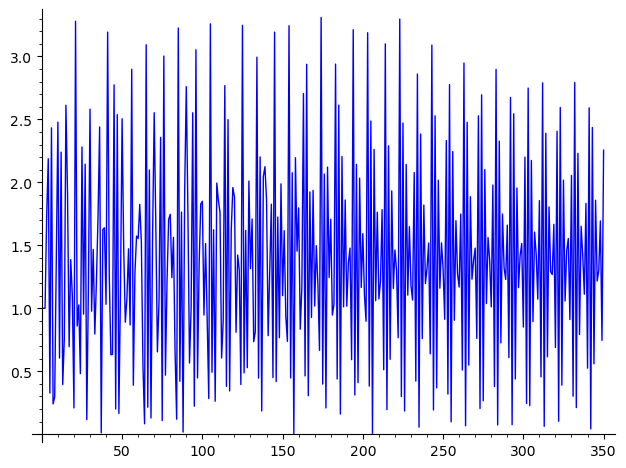

In [8]:
from sage.all import *
import pickle
precision=400
def galois_orbit_sum(N, k, prec=precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')
    dim=S.dimension()
    print("dimension:",dim)
    print()
    R.<q> = PowerSeriesRing(QQ, default_prec=prec)

    results = []
    for i, f in enumerate(newforms):
        K = f.base_ring()
        qexp = f.q_expansion(prec)
        deg = 1 if K == QQ else K.degree()

        coeffs = []
        for n in range(prec):
            c = qexp[n]
            coeffs.append(QQ(c) if K == QQ else QQ(K(c).trace()))

        trace_qexp = sum(coeffs[n] * q**n for n in range(prec)) + O(q**prec)

        print(f"Orbit {i}: degree {deg} over Q")
        print()
        print(f"coefficients: {coeffs[1:20]}")
        print()
        results.append(coeffs)
    print("number of orbits:",len(results))

    return results
    
N=11
k=4
gos=galois_orbit_sum(N,k)


h_list=[1]+gos[0] # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    if j_n%100==0: # change this condition in future
        print(("j_list",n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run29mar26no11.txt', 'wb') as wfile:
    pickle.dump(gos[0], wfile) 
    
with open('/Users/barrybrent/data2/run29mar26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    print(n)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run29mar26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run29mar26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run29mar26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped

In [10]:
short=gos[0][1:20]
print(short)

[2, 2, -2, -8, 2, -26, 20, -12, 44, 50, -22, -40, 80, -4, -194, -8, -124, 92, 72]


In [13]:
# not multiplicative
print(short)
a=[0]+[short][0]
print(a)
b=[x/2 for x in a]
print(b)
print(b[2*3]-b[2]*b[3])
                

[2, 2, -2, -8, 2, -26, 20, -12, 44, 50, -22, -40, 80, -4, -194, -8, -124, 92, 72]
[0, 2, 2, -2, -8, 2, -26, 20, -12, 44, 50, -22, -40, 80, -4, -194, -8, -124, 92, 72]
[0, 1, 1, -1, -4, 1, -13, 10, -6, 22, 25, -11, -20, 40, -2, -97, -4, -62, 46, 36]
-12
